<a href="https://colab.research.google.com/github/AryanAfzal2906/Hate-Speech-Toxic-Detection-NLP/blob/main/Hate_Speech_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!unzip Dataset.zip


Archive:  Dataset.zip
  inflating: train.csv               


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


In [4]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
data = pd.read_csv("train.csv")
data.head()


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
data['toxic_label'] = data[
    ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
].max(axis=1)

data[['comment_text','toxic_label']].head()


,comment_text,toxic_label
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text


In [8]:
data['cleaned_text'] = data['comment_text'].apply(clean_text)


In [9]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(data['cleaned_text'])
y = data['toxic_label']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [12]:
y_pred = model.predict(X_test)


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)


Accuracy : 0.9557888140372865
Precision: 0.9122807017543859
Recall   : 0.625154130702836


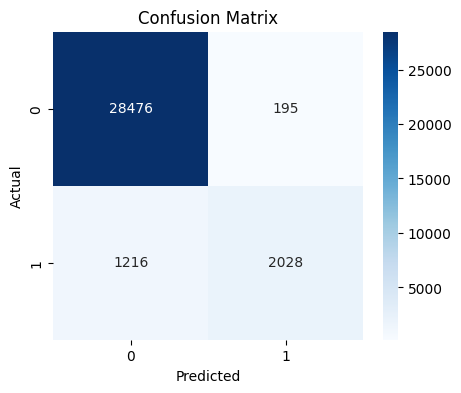

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


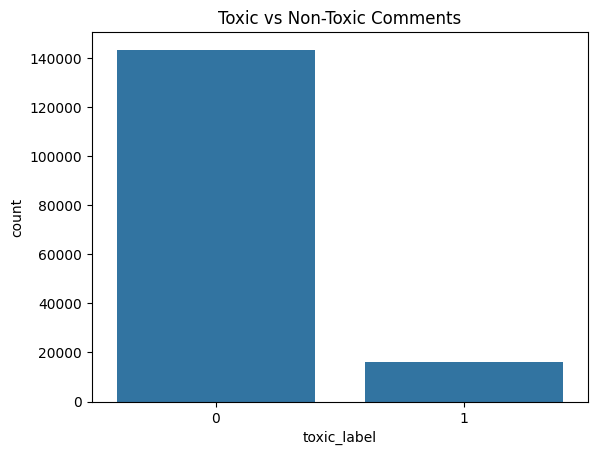

In [15]:
sns.countplot(x=y)
plt.title("Toxic vs Non-Toxic Comments")
plt.show()


In [16]:
import pickle

pickle.dump(model, open("toxic_model.pkl", "wb"))


In [17]:
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))


# **TESTING **


In [18]:
sample = ["You are a disgusting human being"]
sample_clean = [clean_text(sample[0])]
sample_vec = tfidf.transform(sample_clean)

prediction = model.predict(sample_vec)

print("Toxic" if prediction[0] == 1 else "Non-Toxic")


Toxic


# Testing no 2


In [19]:
sample = ["You are a Good human being"]
sample_clean = [clean_text(sample[0])]
sample_vec = tfidf.transform(sample_clean)

prediction = model.predict(sample_vec)

print("Toxic" if prediction[0] == 1 else "Non-Toxic")

Non-Toxic
